Customer Data:
    Spend_Per_Visit  Visit_Frequency
0              5000               50
1              5200               48
2              4800               52
3              1500               10
4              1600               12
5              1400                9
6              3000               25
7              3100               27
8              2900               24
9              8000                5
10              200                2

Clustered Data:
    Spend_Per_Visit  Visit_Frequency  Cluster
0              5000               50        0
1              5200               48        0
2              4800               52        0
3              1500               10        1
4              1600               12        1
5              1400                9        1
6              3000               25        2
7              3100               27        2
8              2900               24        2
9              8000                5       -1
10              20

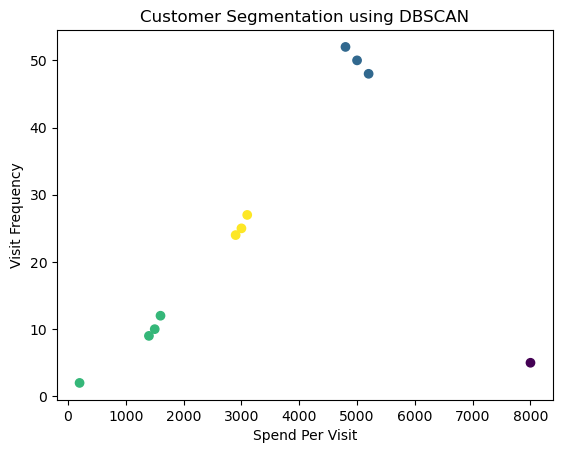

In [2]:
# Scenario: Customer Segmentation for a Retail Store
# Context:
# A retail store wants to understand its customers better. 
# They have data on how much each customer spends per visit and how frequently they visit the store. 
# The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN,
# which is great for finding clusters of varying shapes and identifying outliers.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Customer data: [Spend_Per_Visit, Visit_Frequency]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2],                             # Outlier: very low engagement
])

# Create DataFrame with column names
df = pd.DataFrame(data, columns=["Spend_Per_Visit", "Visit_Frequency"])

print("Customer Data:")
print(df)

# # Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=2)
clusters = dbscan.fit_predict(scaled_data)

# Add cluster labels
df["Cluster"] = clusters

print("\nClustered Data:")
print(df)

# Plot clusters
plt.scatter(df["Spend_Per_Visit"], df["Visit_Frequency"], c=df["Cluster"])

plt.xlabel("Spend Per Visit")
plt.ylabel("Visit Frequency")
plt.title("Customer Segmentation using DBSCAN")

plt.show()